## ***ENVIRONMENT SETUP***


## Setting Up the Environment

Before we begin implementing attacks, we need to set up our Python environment
with the necessary libraries and configurations.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q torch torchvision ipywidgets tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.1 MB/s eta 0:00:00


### Import Libraries

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import random
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib inline
import matplotlib.pyplot as plt
import time

### Reproducibility Setup

For reproducible experiments, we seed all random number generators. This ensures
that running the notebook multiple times produces identical results.

In [ ]:
def seed_all(seed=42):
    """Set seeds for reproducibility across all libraries"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)
print("✓ Random seeds set for reproducibility")

✓ Random seeds set for reproducibility


### Device Configuration

We automatically detect the best available hardware (GPU/TPU/CPU) for training
and inference. Modern Colab notebooks may have access to various accelerators.

In [ ]:
# Device selection: try torch.accelerator when available, otherwise fallback to CUDA/CPU
try:
    if hasattr(torch, 'accelerator') and torch.accelerator.is_available():
        acc = torch.accelerator.current_accelerator().type
        device = torch.device(acc)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
except Exception as e:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

Device: cpu


## ***DATASET PREPARATION***

## MNIST Dataset

We use MNIST (Modified National Institute of Standards and Technology) database:
- 60,000 training images
- 10,000 test images
- 28×28 grayscale images of handwritten digits (0-9)
- Classic benchmark for image classification

### Normalization Strategy

We normalize images using MNIST statistics:
- Mean: 0.1307
- Std: 0.3081

This centers the data around zero and scales variance, improving training
stability and convergence.

**Important**: When attacking normalized models, we must:
1. Apply attacks in normalized space
2. Convert epsilon from pixel scale [0,1] to normalized scale
3. Clip adversarial examples to valid normalized range

In [ ]:
# MNIST dataset with standard normalization
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts PIL Image to tensor and scales to [0, 1]
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))  # Normalize to standard distribution
])

# Download and prepare datasets
trainset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
testset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Create data loaders for batch processing
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2) # We can increase the batch size since we don't have gradients so more space in the GPU memory

print(f'✓ Dataset loaded')
print(f'  Training samples: {len(trainset):,}')
print(f'  Test samples: {len(testset):,}')
print(f'  Image shape: {trainset[0][0].shape}')
print(f'  Number of classes: {len(trainset.classes)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.04MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.36MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.7MB/s]


✓ Dataset loaded
  Training samples: 60,000
  Test samples: 10,000
  Image shape: torch.Size([1, 28, 28])
  Number of classes: 10


This kind of attack is called white attack. It means that the attacker knows which is the architecture of the model

## ***MODEL ARCHITECTURE***

## LeNet-Style CNN Architecture

We use a LeNet-inspired convolutional neural network. LeNet was one of the first
successful CNNs, developed by Yann LeCun in 1998 for digit recognition.

### Architecture Overview:

1. **Convolutional Layers**:
   - Conv1: 1 → 32 channels, 3×3 kernel
   - Conv2: 32 → 64 channels, 3×3 kernel
   - Extract hierarchical features from raw pixels

2. **Pooling**: 2×2 max pooling reduces spatial dimensions

3. **Dropout**:
   - After conv layers (25%): Prevents feature map overfitting
   - After FC layer (50%): Prevents classifier overfitting

4. **Fully Connected Layers**:
   - FC1: 9216 → 128 (feature extraction)
   - FC2: 128 → 10 (classification)

5. **Output**: Log-softmax for numerical stability with NLLLoss

### Why This Architecture?

- **Simple but effective**: ~98%+ accuracy on MNIST
- **Fast to train**: Converges in a few epochs
- **Educational**: Clear structure for understanding attacks
- **Standard benchmark**: Widely used in adversarial ML research


In [ ]:
class Net(nn.Module):
    def __init__(self):
      super(Net, self).__init__()
      self.conv1 = nn.Conv2d(1, 32, 3, 1)
      self.conv2 = nn.Conv2d(32, 64, 3, 1)

      # Regularization
      self.dropout1 = nn.Dropout(0.25)
      self.dropout2 = nn.Dropout(0.5)

      # Fully connected layers
      # 9216 comes from 64*12*12 which is the output dimension after
      # the convolutions and the dropout are applied
      self.fc1 = nn.Linear(9216, 128)
      self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
      # Conv1
      # Initial x shape is (1, 28, 28)
      x = self.conv1(x)
      x = F.relu(x)

      # x shape after conv1 is (32,26,26)
      # the formula used is the markdown cell below

      # Conv2
      x = self.conv2(x)
      x = F.relu(x)
      # shape of x after the conv2 is (64,24,24)

      x = F.max_pool2d(x,2)
      x = self.dropout1(x)
      # shape of x after max_pool2d is (64,12,12)
      #formula below

      # Fully connected layers
      x = torch.flatten(x, 1)
      x = self.fc1(x)
      x = F.relu(x)
      x = self.dropout2(x)
      x = self.fc2(x)

      output = F.log_softmax(x, dim= 1)
      return output

# Initialize model and move to device
model = Net().to(device)
print(model)
print(f'\n✓ Model created with {sum(p.numel() for p in model.parameters()):,} parameters')

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

✓ Model created with 1,199,882 parameters


The formual used to compute the output dimension of the convolutional layer is:
${{W-k+2P}\over{S}}+1$
  
where:

1.   W is the width of the input
2.   k is the kernel size
3.   P is the padding
4.   S is the stride

The formula used for the computation of the max_pool2d operation is:
  
$⌊ {{i-k}\over{s}}⌋+1$

where $i$ is the input size (like W above). If the stride is note inputed in the code line then the kernel size is taken


### Loading Pretrained Model

For this tutorial, we use a pretrained model to ensure high baseline accuracy.
This allows us to better demonstrate the effectiveness of adversarial attacks.

**Note**: If you don't have a pretrained model:
1. Train using standard SGD/Adam for a few epochs (~5-10)
2. Save checkpoint: `torch.save(model.state_dict(), 'lenet_mnist.pth')`
3. Update the path below

In [ ]:
# Load pretrained model option
PRETRAINED_MODEL = '/content/drive/MyDrive/ML_Lab/3/lenet_mnist_model.pth'

if PRETRAINED_MODEL:
    try:
        if PRETRAINED_MODEL.startswith('http'):
            print('Downloading checkpoint...')
            !wget -q -O /content/mnist_lenet_pretrained.pth "{PRETRAINED_MODEL}"
            ckpt_path = '/content/mnist_lenet_pretrained.pth'
        else:
            ckpt_path = PRETRAINED_MODEL

        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        model.eval()
        print(f'✓ Loaded checkpoint from {ckpt_path}')

        # Quick accuracy check
        correct = 0
        total = 0
        with torch.no_grad():
            #!!!Write Code for Baseline Accuracy
            for imgs, labels in testloader:
              outputs = model(imgs.to(device))
              _ , predicted = torch.max(outputs.data, 1)
              total += labels.size(0)
              correct += (predicted.cpu() == labels).sum().item()

        print(f'✓ Baseline accuracy: {100 * correct / total:.2f}%')

    except Exception as e:
        print(f'⚠ Failed to load checkpoint: {e}')
        print('You can train the model using the training cell below.')
else:
    print('⚠ No PRETRAINED_MODEL provided.')
    print('Set PRETRAINED_MODEL to a checkpoint path/URL, or train the model below.')


✓ Loaded checkpoint from /content/drive/MyDrive/ML_Lab/3/lenet_mnist_model.pth
✓ Baseline accuracy: 99.12%


## ***IMPLEMENTING FGSM ATTACK***

## FGSM Attack Implementation

Now we implement the Fast Gradient Sign Method. This is a white-box attack that
requires access to model gradients.

### Implementation Steps:

1. **Enable Gradients**: Set `requires_grad=True` on input images
2. **Forward Pass**: Compute model predictions
3. **Calculate Loss**: Measure error w.r.t. true labels
4. **Backward Pass**: Compute gradient of loss w.r.t. input
5. **Create Perturbation**: δ = ε × sign(gradient)
6. **Generate Adversarial**: x_adv = x + δ
7. **Clamp Values**: Ensure adversarial example is in valid range

### Handling Normalization:

Since our model expects normalized inputs, we must be careful with epsilon:
- User specifies ε in pixel space [0, 1]
- We convert to normalized space: ε_norm = ε / MNIST_STD
- We clamp to normalized range: [(0-mean)/std, (1-mean)/std]

This ensures perturbations are imperceptible in the original image space.

In [ ]:
def unnormalize(img_tensor):
    """
    Convert normalized tensor back to [0, 1] range for visualization

    Args:
        img_tensor: Normalized tensor with shape (N, 1, H, W)

    Returns:
        Unnormalized tensor in [0, 1] range
    """
    return img_tensor * MNIST_STD + MNIST_MEAN

def fgsm_attack(model, images, labels, eps):
    """
    Fast Gradient Sign Method (FGSM) attack

    Args:
        model: Target neural network
        images: Clean input images (normalized)
        labels: True labels for images
        eps: Perturbation budget in original pixel scale [0, 1]

    Returns:
        adv_images: Adversarial examples (normalized)
        sign_grad: Sign of gradient (for visualization)

    Note:
        - Images should be pre-normalized using MNIST statistics
        - eps is specified in pixel space but applied in normalized space
        - Adversarial examples are clamped to valid normalized range
    """
    #!!!write attack code!!!
    model.eval()    # the model is frozen (it isn't in training phase)

    # copy the images so to not modify the original tensor
    # for .detach() look in the markdown cell below
    images = images.clone().detach().to(device)
    labels = labels.to(device)  #labels have to be in the same device as the images

    images.requires_grad = True
    outputs = model(images)
    loss = F.nll_loss(outputs, labels)

    # remove any lefover gradient computation so to be sure that the gradient is
    # the one of the last image passed
    model.zero_grad()
    # get the gradient
    loss.backward()

    eps_norm = eps/ MNIST_STD

    sign_grad = images.grad.data.sign()

    adv_images = images + eps_norm * sign_grad
    min_norm = (0.0 - MNIST_MEAN) / MNIST_STD
    max_norm = (1.0 - MNIST_MEAN) / MNIST_STD

    # we clamp the values of the images to be sure that all the values stay in
    # the image range
    adv_images = torch.clamp(adv_images, min_norm, max_norm)
    return adv_images.detach(), sign_grad.detach()



print("✓ FGSM attack function defined")


✓ FGSM attack function defined


`.detach()`: This method creates a new tensor that shares the same data as the original images tensor but is detached from the current computation graph. This means that PyTorch will not track operations on adv_images for gradient computation. In the context of FGSM, we want to calculate gradients with respect to the input image, but we don't need to track the history of the input image itself for subsequent operations after we've prepared it for gradient computation. It essentially freezes the value of the tensor from the perspective of gradient calculation for anything before this point.

### Understanding the Attack Parameters:

**Epsilon (ε)**: The perturbation budget
- ε = 0.0: No perturbation (clean images)
- ε = 0.05: Barely perceptible noise
- ε = 0.1: Visible but still subtle
- ε = 0.3: Clearly visible perturbations

**Typical Values**:
- MNIST: ε ∈ [0.1, 0.3] commonly used
- CIFAR-10: ε ∈ [0.03, 0.1] (8/255 to 25/255)
- ImageNet: ε ∈ [0.01, 0.03]

The choice of ε balances attack success vs. perceptibility.

## ***PREDICTION & EVALUATION UTILITIES***

## Helper Functions for Evaluation

We need utilities to:
1. Make predictions on images
2. Extract probability distributions
3. Evaluate attack success rates
4. Measure model robustness

In [ ]:
softmax = nn.Softmax(dim=1)

def predict_probs(model, imgs_normalized):
    """
    Get predictions and probability distributions

    Args:
        model: Neural network
        imgs_normalized: Normalized input images

    Returns:
        preds: Predicted class indices
        probs: Probability distribution over classes
    """
    model.eval()
    with torch.no_grad():
        logits = model(imgs_normalized.to(device))
        probs = softmax(logits).cpu().numpy()
        preds = np.argmax(probs, axis=1)
    return preds, probs

def eval_adv_accuracy(model, dataloader, eps):
    """
    Evaluate model accuracy on adversarial examples

    Args:
        model: Target model
        dataloader: Data loader for evaluation
        eps: FGSM epsilon value

    Returns:
        accuracy: Fraction of correctly classified adversarial examples
    """
    model.eval()
    correct = 0
    total = 0

    for imgs, labels in dataloader:
        # Generate adversarial examples
        adv, _ = fgsm_attack(model, imgs, labels, eps)

        # Get predictions
        preds, _ = predict_probs(model, adv)

        # Count correct predictions
        correct += (preds == labels.numpy()).sum()
        total += labels.size(0)

    return correct / total

print("✓ Evaluation utilities defined")

✓ Evaluation utilities defined


## ***VISUALIZATION - ACCURACY VS EPSILON***

## Accuracy vs Epsilon

One of the most fundamental experiments in adversarial ML is measuring how
model accuracy degrades as we increase the perturbation budget (epsilon).

### What to Expect:

- **ε = 0**: Baseline clean accuracy (~98-99% for our model)
- **Small ε (0.05-0.1)**: Accuracy drops significantly
- **Large ε (0.2-0.3)**: Model is completely fooled (near random guessing)

This demonstrates that even tiny perturbations can break ML models.

### Interpretation:

- **Steep drop**: Model is vulnerable to adversarial examples
- **Gradual drop**: More robust (but still vulnerable)
- **Ideal**: Flat line (perfect robustness - very hard to achieve)

**This curve is a key metric for evaluating adversarial robustness.**

In [ ]:
def plot_accuracy_vs_epsilon(model, dataloader, epsilons=None):
    """
    Plot model accuracy as a function of FGSM epsilon

    Args:
        model: Target neural network
        dataloader: Evaluation data
        epsilons: List of epsilon values to test
    """
    if epsilons is None:
        epsilons = np.linspace(0.0, 0.3, 13)

    print("Evaluating accuracy for different epsilon values...")
    print("This may take a few minutes...\n")

    accs = []
    for eps in tqdm(epsilons, desc="Testing epsilon values"):
        acc = eval_adv_accuracy(model, dataloader, eps)
        accs.append(acc)
        print(f'ε = {eps:.3f} → accuracy = {acc:.4f} ({acc*100:.1f}%)')

    # Plot results
    plt.figure(figsize=(8, 5))
    plt.plot(epsilons, accs, marker='o', linewidth=2, markersize=8)
    plt.axhline(y=0.1, color='r', linestyle='--', alpha=0.3, label='Random guessing')
    plt.xlabel('Epsilon (L∞ norm, pixel scale [0,1])', fontsize=12)
    plt.ylabel('Accuracy on adversarial examples', fontsize=12)
    plt.title('Model Robustness: Accuracy vs FGSM Epsilon', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n{'='*60}")
    print("SUMMARY STATISTICS")
    print(f"{'='*60}")
    print(f"Clean accuracy (ε=0):        {accs[0]:.4f} ({accs[0]*100:.1f}%)")
    print(f"Accuracy at ε=0.1:           {accs[np.argmin(np.abs(epsilons - 0.1))]:.4f}")
    print(f"Accuracy at ε=0.3:           {accs[-1]:.4f}")
    print(f"Accuracy drop (0 → 0.3):     {(accs[0] - accs[-1])*100:.1f}%")
    print(f"{'='*60}")

## ***INTERACTIVE VISUALIZATION***

## Interactive Adversarial Examples Explorer

This interactive widget lets you explore adversarial examples in real-time:

### Controls:
- **Index slider**: Select which test image to attack
- **Epsilon slider**: Adjust perturbation strength

### Visualizations:
1. **Original Image**: Clean input with true label and model's prediction
2. **Original Probabilities**: Model's confidence distribution over classes
3. **Adversarial Image**: Attacked version (usually looks identical to human)
4. **Adversarial Probabilities**: Changed confidence distribution
5. **Perturbation**: The noise added (scaled 10× for visibility)

### What to Observe:

- How small perturbations (ε=0.05-0.1) can flip predictions
- Model confidence remains high even when wrong
- Perturbations often look like random noise
- Some examples are more robust than others

**Try adjusting epsilon slowly and watch the prediction change!**

In [ ]:
# Prepare raw test images for visualization
raw_test_images = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
).data.unsqueeze(1).float() / 255.0

test_labels = torch.tensor(datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
).targets)

def show_example(idx=0, eps=0.1):
    """
    Interactive function to display adversarial example

    Args:
        idx: Index of test image
        eps: FGSM epsilon value
    """
    clear_output(wait=True)

    # Get clean image and label
    img_norm, label = testset[idx][0].unsqueeze(0), torch.tensor([test_labels[idx]])

    # Generate adversarial example
    adv_norm, grad = fgsm_attack(model, img_norm, label, eps)

    # Unnormalize for visualization
    img_disp = unnormalize(img_norm).squeeze().cpu().numpy()
    adv_disp = unnormalize(adv_norm).squeeze().cpu().numpy()

    # Get predictions and probabilities
    pred_orig, prob_orig = predict_probs(model, img_norm)
    pred_adv, prob_adv = predict_probs(model, adv_norm)

    # Determine if attack succeeded
    attack_success = pred_orig[0] != pred_adv[0]
    success_marker = "✓ ATTACK SUCCEEDED" if attack_success else "✗ Attack failed"

    # === ORIGINAL IMAGE ===
    plt.figure(figsize=(4, 4))
    plt.title(
        f'Original Image\n'
        f'True Label: {int(label.item())} | '
        f'Predicted: {int(pred_orig[0])} '
        f'(confidence: {prob_orig[0][pred_orig[0]]:.1%})',
        fontsize=11, fontweight='bold'
    )
    plt.imshow(img_disp, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # === ORIGINAL PROBABILITIES ===
    plt.figure(figsize=(8, 3))
    colors = ['green' if i == label.item() else 'gray' for i in range(10)]
    bars = plt.bar(np.arange(10), prob_orig[0], color=colors, alpha=0.7)
    bars[pred_orig[0]].set_edgecolor('blue')
    bars[pred_orig[0]].set_linewidth(3)
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.ylabel('Probability')
    plt.title('Original Prediction Probabilities (blue=predicted, green=true)', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # === ADVERSARIAL IMAGE ===
    plt.figure(figsize=(4, 4))
    plt.title(
        f'Adversarial Image (ε={eps:.3f}) {success_marker}\n'
        f'Predicted: {int(pred_adv[0])} '
        f'(confidence: {prob_adv[0][pred_adv[0]]:.1%})',
        fontsize=11, fontweight='bold',
        color='red' if attack_success else 'orange'
    )
    plt.imshow(adv_disp, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # === ADVERSARIAL PROBABILITIES ===
    plt.figure(figsize=(8, 3))
    colors = ['green' if i == label.item() else 'gray' for i in range(10)]
    bars = plt.bar(np.arange(10), prob_adv[0], color=colors, alpha=0.7)
    bars[pred_adv[0]].set_edgecolor('red')
    bars[pred_adv[0]].set_linewidth(3)
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.ylabel('Probability')
    plt.title('Adversarial Prediction Probabilities (red=predicted, green=true)', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # === PERTURBATION ===
    pert = (adv_disp - img_disp)
    plt.figure(figsize=(4, 4))
    plt.title(
        f'Perturbation (scaled ×10 for visibility)\n'
        f'L∞ norm: {np.max(np.abs(pert)):.4f} | '
        f'L2 norm: {np.linalg.norm(pert):.4f}',
        fontsize=10
    )
    plt.imshow(pert * 10 + 0.5, cmap='gray')
    plt.colorbar(label='Perturbation intensity')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Create interactive widgets
idx_widget = widgets.IntSlider(
    value=0,
    min=0,
    max=len(testset)-1,
    step=1,
    description='Sample Index:',
    style={'description_width': '100px'}
)

eps_widget = widgets.FloatSlider(
    value=0.1,
    min=0.0,
    max=0.5,
    step=0.01,
    description='Epsilon (ε):',
    style={'description_width': '100px'},
    readout_format='.3f'
)

ui = widgets.VBox([
    widgets.HTML('<h3>Interactive Adversarial Examples Explorer</h3>'),
    idx_widget,
    eps_widget
])

out = widgets.interactive_output(show_example, {'idx': idx_widget, 'eps': eps_widget})
display(ui, out)

### Experiment Instructions:

1. **Start with ε=0**: Observe clean prediction (should be correct)
2. **Gradually increase ε**: Watch when the prediction flips
3. **Try different samples**: Some are more robust than others
4. **Note the perturbation**: Often imperceptible but effective

**Challenge**: Find the minimum ε that causes misclassification for different samples

**Image placeholder: The grid will appear above this cell**

### Observations to Make:

1. **ε = 0.0**: All predictions should be correct (baseline)
2. **ε = 0.05**: Some attacks may start succeeding
3. **ε = 0.1-0.2**: Many attacks succeed
4. **ε = 0.3**: Nearly all attacks succeed, perturbations may be visible

### Analysis Questions:

- At what epsilon do perturbations become visible to you?
- Are certain digits (e.g., 1 vs 8) more robust than others?
- Does the model tend to confuse similar-looking digits?


#REPORT ASSIGNMENT ONLY!

## ***EVALUATION METRICS & ANALYSIS***

## Evaluation Metrics for Adversarial Robustness

Beyond simple accuracy, several metrics help us understand adversarial robustness:

### 1. Attack Success Rate (ASR)
Percentage of clean examples that are successfully misclassified by the attack.

**Formula**: ASR = (# successful attacks) / (# total attempts)

### 2. Robust Accuracy
Accuracy on adversarial examples (1 - ASR for untargeted attacks)

### 3. Perturbation Norms
- **L∞ (L-infinity)**: Maximum per-pixel change: max|δᵢⱼ|
- **L₂ (Euclidean)**: Total energy: √(Σδᵢⱼ²)
- **L₀**: Number of changed pixels: |{(i,j) : δᵢⱼ ≠ 0}|

### 4. Confidence Changes
How much does model confidence change under attack?

### 5. Transferability Rate
Do adversarial examples from one model fool other models?

Let's implement comprehensive evaluation metrics:

In [ ]:
#This is for the report assignment

def attack_success_rate(model, dataloader, eps):
    """
    Calculates the Attack Success Rate (ASR) of an FGSM attack.
    ASR is the percentage of adversarial examples that successfully
    fool the model into making an incorrect prediction.
    """
    # Set the model to evaluation mode (disables dropout, fixes batch norm)
    model.eval()


    successful_attacks = 0
    total_images = 0

    for imgs, labels in dataloader:
        # Generate adversarial examples for the current batch
        adv, _ = fgsm_attack(model, imgs, labels, eps)

        # Get the model's predictions on adversarial images
        preds, _ = predict_probs(model, adv)

        # 3. Count how many examples were successfully misclassified.
        successful_attacks += (preds != labels.numpy()).sum()


        total_images += labels.size(0)

    result = successful_attacks / total_images
    print(f"Attack success rate = {result}")
    return result


def robust_accuracy(model, dataloader, eps):
    """
    Calculates the Robust Accuracy of the model against an FGSM attack.
    """
    # Because an example is either misclassified or correctly classified,
    # robust accuracy is simply 1.0 minus the Attack Success Rate.
    result = 1 - attack_success_rate(model, dataloader, eps)
    print(f"Robust accuracy = {result}")
    return result

def l_inf_norm(model, dataloader, eps):
    """
    Computes the maximum L-infinity norm (maximum per-pixel perturbation)
    across the entire dataset.
    """
    current_max_diff = 0

    for imgs, labels in dataloader:
        # Generate adversarial examples for the current batch
        adv, _ = fgsm_attack(model, imgs, labels, eps)

        # Calculate the L-infinity norm for this specific batch:
        diff = torch.max(torch.abs(imgs - adv))

        # Update the global maximum if the current batch has a larger perturbation
        if diff > current_max_diff:
            current_max_diff = diff

    result = current_max_diff.item()
    print(f"L_inf norm= {result}")
    return result

def avg_l_2_norm(model, dataloader, eps):
    """
    Computes the average L2 (Euclidean) norm of adversarial perturbations
    generated by an FGSM attack across the entire dataset.
    """
    total_l2_norm = 0.0
    total_images = 0

    for imgs, labels in dataloader:
        # Generate adversarial examples for the current batch
        adv, _ = fgsm_attack(model, imgs, labels, eps)

        # Calculate the L2 norm for each image in the batch.
        l2_norms = torch.sqrt(torch.sum((imgs - adv)**2, dim=(1, 2, 3)))

        total_l2_norm += torch.sum(l2_norms).item()


        total_images += imgs.size(0)

    avg_l2 = total_l2_norm / total_images
    print(f"L_2 norm = {avg_l2}")
    return avg_l2


def l_zero_norm(model, dataloader, eps):
    """
    Computes the average L0 norm of adversarial perturbations generated by an
    FGSM attack. The L0 norm counts the exact number of pixels that were
    altered by the attack, regardless of the magnitude of the change.
    """
    total_changed = 0
    total_images = 0

    for imgs, labels in dataloader:
        # Generate adversarial examples for the current batch
        adv, _ = fgsm_attack(model, imgs, labels, eps)

        # Calculate the raw difference between the adversarial and original images
        diff = adv - imgs

        # Identify which pixels were changed.
        # Use a tiny numerical tolerance (> 1e-6) instead of strict equality (!= 0)
        # to account for standard floating-point imprecision in PyTorch calculations.
        changed_pixels = torch.abs(diff) > 1e-6

        total_changed += torch.sum(changed_pixels).item()

        total_images += imgs.size(0)

    avg_l0 = total_changed / total_images

    pixels_per_image = imgs.size(1) * imgs.size(2) * imgs.size(3)
    print(f"Average L0 norm: {avg_l0:.2f} (out of {pixels_per_image}).")

    print(f"L_0 norm = {avg_l0}")
    return avg_l0



In [ ]:
def calculate_confidence_changes(model, dataloader, eps):
    """
    Evaluates how an FGSM attack affects the model's prediction confidence.

    It calculates three metrics:
      1. Clean True Confidence: how confident the model is in the correct label before the attack.
      2. Adversarial True Confidence: how confident the model is in the correct label after the attack.
      3. Adversarial Predicted Confidence: how confident the model is in its (likely incorrect) new prediction.
    """

    model.eval()

    # Initialize accumulators the metrics
    avg_true_conf_clean = 0.0
    avg_true_conf_adv = 0.0
    avg_adv_pred_conf = 0.0
    total_samples = 0

    for imgs, labels in dataloader:
        # Move inputs and labels to the designated hardware device
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Get the model's logits for the original, unaltered images
        outputs_clean = model(imgs)
        # Convert raw logits into probabilities using softmax
        probs_clean = softmax(outputs_clean)
        # Identify the class with the highest probability
        preds_clean = torch.argmax(probs_clean, dim=1)

        # Create the perturbed images using the FGSM attack
        adv_imgs, _ = fgsm_attack(model, imgs, labels, eps)

        # Get the model's logits for the newly perturbed images
        outputs_adv = model(adv_imgs)
        # Convert the adversarial logits into probabilities
        probs_adv = softmax(outputs_adv)
        # Identify the model's new predicted class for the adversarial images
        preds_adv = torch.argmax(probs_adv, dim=1)


        for i in range(imgs.size(0)):
            # look up the probability assigned to the true class
            avg_true_conf_clean += probs_clean[i, labels[i]].item()

            # look up the probability assigned to the true class after the attack
            avg_true_conf_adv += probs_adv[i, labels[i]].item()

            # look up the probability assigned to the class the model actually chose
            avg_adv_pred_conf += probs_adv[i, preds_adv[i]].item()

        # running total of the number of images processed
        total_samples += imgs.size(0)


    if total_samples > 0:
        avg_true_conf_clean /= total_samples
        avg_true_conf_adv /= total_samples
        avg_adv_pred_conf /= total_samples


    #print(f"\nConfidence Changes (ε={eps:.3f}):")
    print(f"  Avg. Confidence in True Label (Clean):  {avg_true_conf_clean:.2%}")
    print(f"  Avg. Confidence in True Label (Adv):    {avg_true_conf_adv:.2%}")
    print(f"  Avg. Confidence in Adversarial Pred.:   {avg_adv_pred_conf:.2%}")
    print(f"  Drop in True Label Confidence:          {(avg_true_conf_clean - avg_true_conf_adv):.2%}")

    # Return a dictionary of the final metrics for further analysis
    return {
        'avg_true_conf_clean': avg_true_conf_clean,
        'avg_true_conf_adv': avg_true_conf_adv,
        'avg_adv_pred_conf': avg_adv_pred_conf
    }

In [ ]:
# Example usage:
epsilons_to_test = [0.0, 0.1, 0.2, 0.3]
for eps_val in epsilons_to_test:
    print(f'ε={eps_val}')
    attack_success_rate(model, testloader, eps_val)
    robust_accuracy(model, testloader, eps_val)
    l_inf_norm(model, testloader, eps_val)
    avg_l_2_norm(model, testloader, eps_val)
    l_zero_norm(model, testloader, eps_val)
    calculate_confidence_changes(model, testloader, eps_val)
    print("\n")

ε=0.0
Attack success rate = 0.0088
Attack success rate = 0.0088
Robust accuracy = 0.9912
L_inf norm= 2.384185791015625e-07
L_2 norm = 8.765618575125699e-07
Average L0 norm: 0.00 (out of 784).
L_0 norm = 0.0
  Avg. Confidence in True Label (Clean):  98.95%
  Avg. Confidence in True Label (Adv):    98.95%
  Avg. Confidence in Adversarial Pred.:   99.45%
  Drop in True Label Confidence:          -0.00%


ε=0.1
Attack success rate = 0.1257
Attack success rate = 0.1257
Robust accuracy = 0.8743
L_inf norm= 0.32457005977630615
L_2 norm = 5.540166159057617
Average L0 norm: 311.92 (out of 784).
L_0 norm = 311.9167
  Avg. Confidence in True Label (Clean):  98.95%
  Avg. Confidence in True Label (Adv):    82.53%
  Avg. Confidence in Adversarial Pred.:   90.65%
  Drop in True Label Confidence:          16.42%


ε=0.2
Attack success rate = 0.5124
Attack success rate = 0.5124
Robust accuracy = 0.48760000000000003
L_inf norm= 0.6491400003433228
L_2 norm = 10.974371810913086
Average L0 norm: 311.92 (o

Evaluating confidence changes for different epsilon values...


Testing epsilon values:  25%|██▌       | 1/4 [00:27<01:23, 27.75s/it]

  Avg. Confidence in True Label (Clean):  98.95%
  Avg. Confidence in True Label (Adv):    98.95%
  Avg. Confidence in Adversarial Pred.:   99.45%
  Drop in True Label Confidence:          -0.00%


Testing epsilon values:  50%|█████     | 2/4 [00:56<00:56, 28.05s/it]

  Avg. Confidence in True Label (Clean):  98.95%
  Avg. Confidence in True Label (Adv):    82.53%
  Avg. Confidence in Adversarial Pred.:   90.65%
  Drop in True Label Confidence:          16.42%


Testing epsilon values:  75%|███████▌  | 3/4 [01:26<00:29, 29.26s/it]

  Avg. Confidence in True Label (Clean):  98.95%
  Avg. Confidence in True Label (Adv):    33.51%
  Avg. Confidence in Adversarial Pred.:   58.02%
  Drop in True Label Confidence:          65.44%


Testing epsilon values: 100%|██████████| 4/4 [01:57<00:00, 29.40s/it]

  Avg. Confidence in True Label (Clean):  98.95%
  Avg. Confidence in True Label (Adv):    13.82%
  Avg. Confidence in Adversarial Pred.:   46.47%
  Drop in True Label Confidence:          85.13%


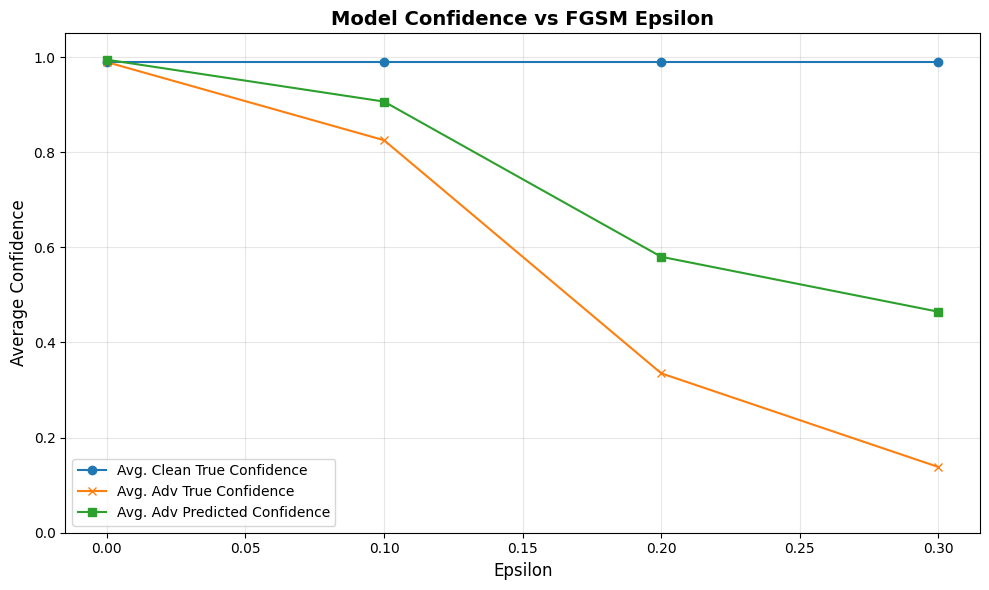

In [ ]:
#  Plot Confidence Changes
def plot_confidence_changes(model, dataloader, epsilons=None):
    if epsilons is None:
        epsilons = np.linspace(0.0, 0.3, 13)

    clean_true_confs = []
    adv_true_confs = []
    adv_pred_confs = []

    print("Evaluating confidence changes for different epsilon values...")
    for eps in tqdm(epsilons, desc="Testing epsilon values"):
        metrics = calculate_confidence_changes(model, dataloader, eps)
        clean_true_confs.append(metrics['avg_true_conf_clean'])
        adv_true_confs.append(metrics['avg_true_conf_adv'])
        adv_pred_confs.append(metrics['avg_adv_pred_conf'])

    plt.figure(figsize=(10, 6))
    plt.plot(epsilons, clean_true_confs, marker='o', label='Avg. Clean True Confidence')
    plt.plot(epsilons, adv_true_confs, marker='x', label='Avg. Adv True Confidence')
    plt.plot(epsilons, adv_pred_confs, marker='s', label='Avg. Adv Predicted Confidence')

    plt.xlabel('Epsilon', fontsize=12)
    plt.ylabel('Average Confidence', fontsize=12)
    plt.title('Model Confidence vs FGSM Epsilon', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

# --- Visualize Single Image Transformation and Confidence

def visualize_single_image_attack(model, dataset, idx, epsilons=None):
    if epsilons is None:
        epsilons = [0.0, 0.05, 0.1, 0.2, 0.3]

    # Get original image and label
    img_norm_orig, label_orig = dataset[idx][0].unsqueeze(0), torch.tensor([dataset[idx][1]])

    # Plotting setup
    fig, axes = plt.subplots(len(epsilons), 4, figsize=(15, 3 * len(epsilons)))
    fig.suptitle(f'Adversarial Attack on Sample Index {idx} (True Label: {label_orig.item()})', fontsize=16, fontweight='bold')

    for i, eps in enumerate(epsilons):
        # Generate adversarial example
        adv_norm, grad = fgsm_attack(model, img_norm_orig, label_orig, eps)

        # Unnormalize for visualization
        img_disp = unnormalize(img_norm_orig).squeeze().cpu().numpy()
        adv_disp = unnormalize(adv_norm).squeeze().cpu().numpy()
        pert_disp = (adv_disp - img_disp) # Perturbation for visualization

        # Get predictions and probabilities
        pred_orig, prob_orig = predict_probs(model, img_norm_orig)
        pred_adv, prob_adv = predict_probs(model, adv_norm)

        # Original Image (only show once per row for clarity or just in the first row)
        if i == 0:
            axes[i, 0].imshow(img_disp, cmap='gray')
            axes[i, 0].set_title(f'Original\nPred: {pred_orig[0]} ({prob_orig[0][pred_orig[0]]:.1%})', fontsize=9)
        else:
            axes[i, 0].axis('off') # Hide duplicate original images

        # Adversarial Image
        axes[i, 1].imshow(adv_disp, cmap='gray')
        axes[i, 1].set_title(f'Adv (ε={eps:.2f})\nPred: {pred_adv[0]} ({prob_adv[0][pred_adv[0]]:.1%})',
                             fontsize=9, color='red' if pred_orig[0] != pred_adv[0] else 'black')

        # Perturbation
        im = axes[i, 2].imshow(pert_disp * 10 + 0.5, cmap='gray') # Scale for visibility
        axes[i, 2].set_title(f'Perturbation x10', fontsize=9)
        # Add colorbar only to the last perturbation for clarity
        if i == len(epsilons) - 1:
            fig.colorbar(im, ax=axes[i, 2], orientation='vertical', fraction=0.046, pad=0.04)

        # Confidence Plot
        bar_colors_orig = ['green' if x == label_orig.item() else 'gray' for x in range(10)]
        bar_colors_adv = ['red' if x == pred_adv[0] else ('green' if x == label_orig.item() else 'gray') for x in range(10)]

        ax_conf = axes[i, 3]
        ax_conf.bar(np.arange(10), prob_adv[0], color=bar_colors_adv, alpha=0.7)
        ax_conf.set_ylim(0, 1)
        ax_conf.set_xticks(np.arange(10))
        ax_conf.set_title(f'Adv Probs', fontsize=9)
        ax_conf.tick_params(axis='x', labelsize=7) # Smaller labels for x-axis
        ax_conf.tick_params(axis='y', labelsize=7) # Smaller labels for y-axis
        ax_conf.grid(axis='y', alpha=0.3)

        # Remove y-axis labels for all but the first image column
        for col in [0, 1, 2]:
            axes[i, col].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()

# --- Execution of the plots

# Plot 1: Confidence Changes vs Epsilon
epsilons_for_plot = epsilons_to_test # Use epsilons from previous cell
plot_confidence_changes(model, testloader, epsilons_for_plot)

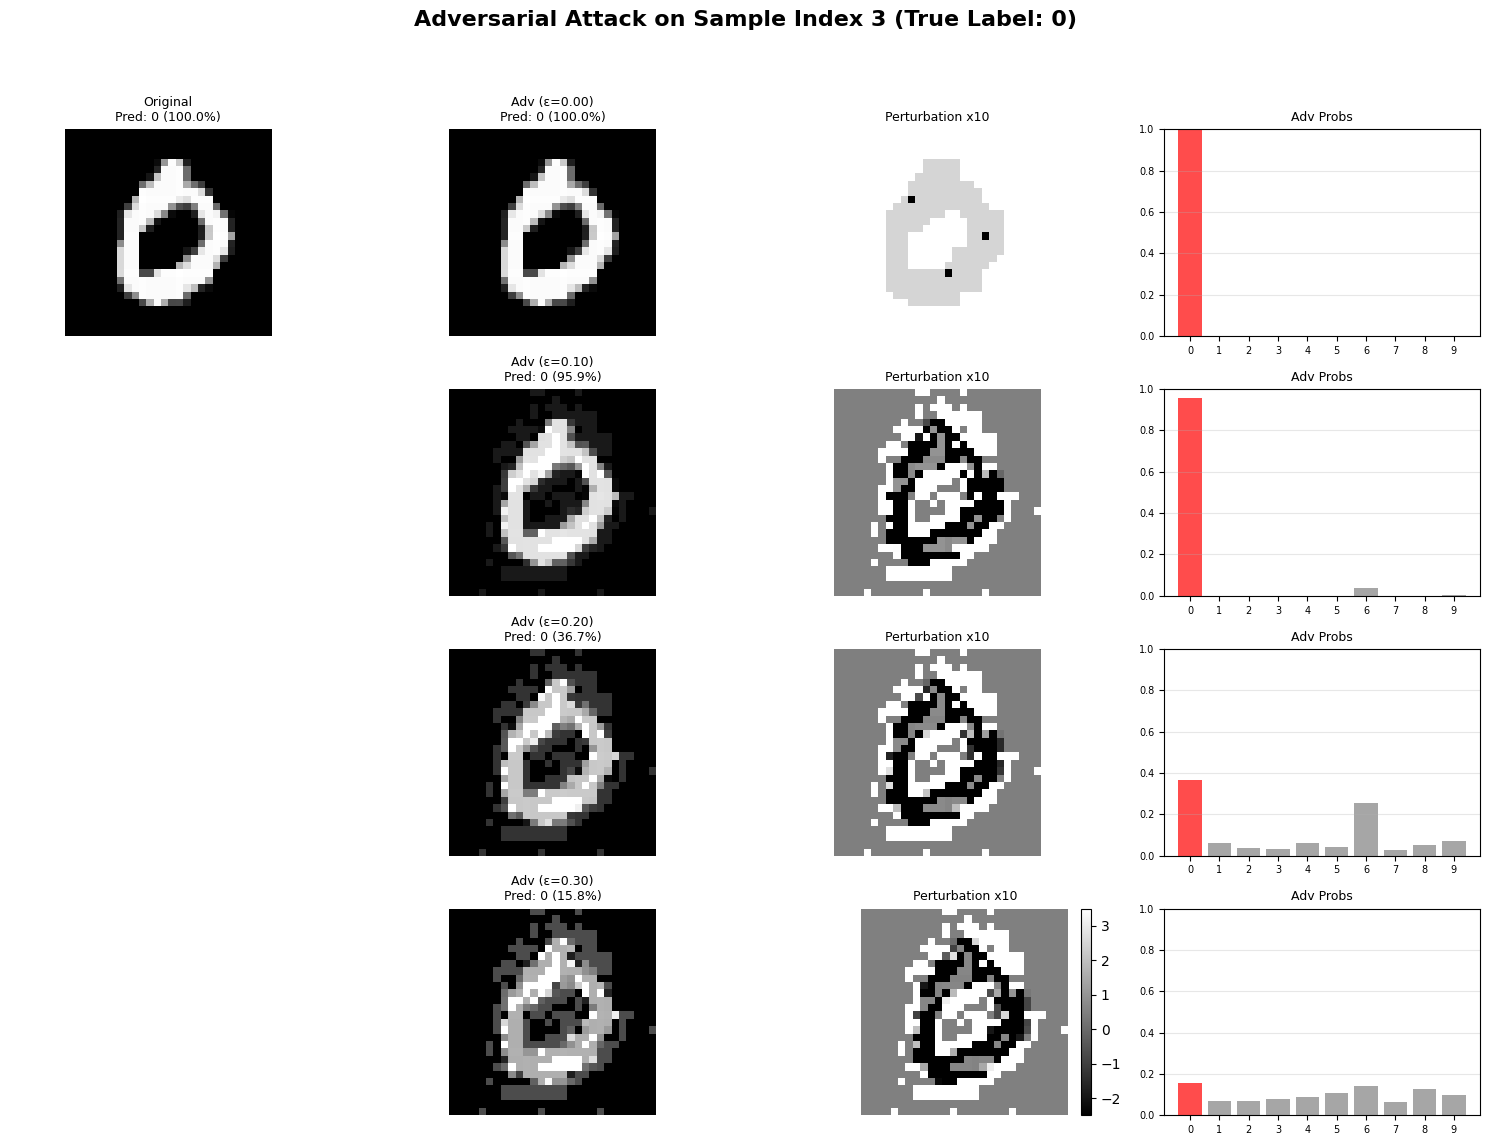

In [ ]:
# Plot 2: Single Image Transformation and Confidence Changes across Epsilon
single_image_idx = 3 # Change this index to visualize a different image
epsilons_for_single_image = [0.0, 0.3] # Reduced epsilon values for a smaller plot
visualize_single_image_attack(model, testset, single_image_idx, epsilons_for_single_image)

Interpretation of the results are in the report.

# Transferability

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """A standard ResNet Block with a skip connection."""
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # First convolutional layer of the block
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Second convolutional layer
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # The Skip Connection (Identity Mapping)
        self.shortcut = nn.Sequential()
        # If dimensions change (due to stride or channel increase), use a 1x1 conv to match them
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Add the skipped input back into the output
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class MiniResNet(nn.Module):
    def __init__(self):
        super(MiniResNet, self).__init__()

        # Initial Convolution
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        # Residual Layers
        self.layer1 = ResidualBlock(16, 16, stride=1)
        self.layer2 = ResidualBlock(16, 32, stride=2)

        # Final Fully Connected Output
        self.fc = nn.Linear(32, 10)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)

        # Global Average Pooling squashes the spatial HxW dimensions down to 1x1
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        out = self.fc(out)


        return F.log_softmax(out, dim=1)

# Initialize the target model and move to device
target_model = MiniResNet().to(device)
print(target_model)
print(f'\n Target Mini-ResNet created with {sum(p.numel() for p in target_model.parameters()):,} parameters')

MiniResNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): ResidualBlock(
    (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential()
  )
  (layer2): ResidualBlock(
    (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

In [ ]:
def train_target_model(model, trainloader, device, epochs=3, learning_rate=0.001):
    """
    Trains the target model on the clean MNIST dataset.
    """
    # Setup Adam optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"Starting Training for {epochs} Epochs...")

    for epoch in range(epochs):
        model.train() # Put the model in training mode (enables BatchNorm)
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        start_time = time.time()

        for batch_idx, (imgs, labels) in enumerate(trainloader):
            # Move data to the correct device
            imgs = imgs.to(device)
            labels = labels.to(device)

            # Zero out the gradients from the previous batch
            optimizer.zero_grad()

            # Forward pass (make predictions)
            outputs = model(imgs)

            # Calculate the loss
            # Use nll_loss because the model outputs log_softmax
            loss = F.nll_loss(outputs, labels)

            # Backward pass (compute gradients)
            loss.backward()

            # Update the model weights
            optimizer.step()

            # Tracking Metrics
            running_loss += loss.item() * imgs.size(0)

            # Calculate accuracy for this batch
            preds = torch.argmax(outputs, dim=1)
            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)

        # Calculate average metrics for the epoch
        epoch_loss = running_loss / total_samples
        epoch_accuracy = correct_predictions / total_samples
        epoch_time = time.time() - start_time

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"| Loss: {epoch_loss:.4f} "
              f"| Accuracy: {epoch_accuracy:.2%} "
              f"| Time: {epoch_time:.1f}s")

    print(" Target Model Training Complete!")



# Ensure your model is on the right device
target_model = target_model.to(device)

# Call the training loop
train_target_model(target_model, trainloader, device, epochs=3)

Starting Training for 3 Epochs...
Epoch [1/3] | Loss: 0.8962 | Accuracy: 81.28% | Time: 72.0s
Epoch [2/3] | Loss: 0.1968 | Accuracy: 96.36% | Time: 71.5s
Epoch [3/3] | Loss: 0.1181 | Accuracy: 97.41% | Time: 75.0s
 Target Model Training Complete!


In [ ]:
def transferability_rate(source_model, target_model, dataloader, eps, device='cpu'):
    """
    Calculates the Transferability Rate of an adversarial attack.
    It generates adversarial examples using a white-box Source Model,
    and tests if those exact same images successfully fool a black-box Target Model.
    """
    # Set both models to evaluation mode
    source_model.eval()
    target_model.eval()

    successful_transfers = 0
    total_images = 0

    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Use the source model's gradients to make the adversarial noise
        adv_imgs, _ = fgsm_attack(source_model, imgs, labels, eps)

        # Pass the adversarial images into the separate target model
        target_outputs = target_model(adv_imgs)

        # Get the predicted classes from the target model
        target_preds = torch.argmax(target_outputs, dim=1)

        # Count the misclassifications
        # A transfer is successful if the target model's prediction does not equal the true label
        successful_transfers += (target_preds != labels).sum().item()
        total_images += labels.size(0)

    # Calculate the final rate
    transfer_rate = successful_transfers / total_images

    print(f"Transferability Rate (ε={eps:.3f}): {transfer_rate:.2%} of attacks fooled the target model.")
    return transfer_rate

In [ ]:
epsilons_to_test = [0.0, 0.1, 0.2, 0.3]
for eps_val in epsilons_to_test:
  transferability_rate(model, target_model, testloader, eps_val)

Transferability Rate (ε=0.000): 2.45% of attacks fooled the target model.
Transferability Rate (ε=0.100): 56.94% of attacks fooled the target model.
Transferability Rate (ε=0.200): 88.58% of attacks fooled the target model.
Transferability Rate (ε=0.300): 90.26% of attacks fooled the target model.


.
  
.
  
.
  
.

.

-  

